# Feature Engineering


| # | Technique | Description |
|---|---|---|
| 1 | Handling Missing Values | Detect and confirm/impute missing data |
| 2 | Encoding Categorical Variables | Ordinal + One-Hot encoding |
| 3 | Creating New Features | Total_Duration, Engagement_Score |
| 4 | Outlier Treatment | Cap extreme values at 99th percentile |
| 5 | Feature Scaling (Standardization) | StandardScaler on all numeric features |
| 6 | Dropping Irrelevant Features | Remove low-value columns |

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/online_shoppers_intention.csv')
print(f'Original dataset shape: {df.shape}')
df.head(3)

Original dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


---
## Technique 1 — Handling Missing Values

In [2]:
print('=== TECHNIQUE 1: Handling Missing Values ===')
print()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

if missing_df['Missing Count'].sum() == 0:
    print('No missing values detected in the dataset.')
    print('No imputation required.')
else:
    print(missing_df[missing_df['Missing Count'] > 0])
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f'  Filled {col} with median')
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f'  Filled {col} with mode')

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'\nDuplicate rows removed: {before - after}')
print(f'Clean dataset shape: {df.shape}')

=== TECHNIQUE 1: Handling Missing Values ===

No missing values detected in the dataset.
No imputation required.

Duplicate rows removed: 125
Clean dataset shape: (12205, 18)


---
## Technique 2 — Encoding Categorical Variables

In [3]:
print('=== TECHNIQUE 2: Encoding Categorical Variables ===')
print()

# --- 2a. Ordinal encoding for Month (preserve seasonal order) ---
month_order = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['Month_Num'] = df['Month'].map(month_order)
print('Month ordinal encoding:')
print(df[['Month', 'Month_Num']].drop_duplicates().sort_values('Month_Num').to_string(index=False))

# --- 2b. One-Hot encoding for VisitorType ---
visitor_dummies = pd.get_dummies(df['VisitorType'], prefix='Visitor', drop_first=False)
df = pd.concat([df, visitor_dummies], axis=1)
print(f'\nVisitorType one-hot columns added: {list(visitor_dummies.columns)}')

# --- 2c. Boolean to integer (Weekend, Revenue) ---
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print(f'\nWeekend & Revenue converted to int (0/1)')
print(f'Revenue value counts:\n{df["Revenue"].value_counts().to_string()}')

# Drop original categorical columns that are now encoded
df.drop(columns=['Month', 'VisitorType'], inplace=True)
print(f'\nDropped original Month and VisitorType columns')
print(f'Shape after encoding: {df.shape}')

=== TECHNIQUE 2: Encoding Categorical Variables ===

Month ordinal encoding:
Month  Month_Num
  Feb          2
  Mar          3
  May          5
 June          6
  Jul          7
  Aug          8
  Sep          9
  Oct         10
  Nov         11
  Dec         12

VisitorType one-hot columns added: ['Visitor_New_Visitor', 'Visitor_Other', 'Visitor_Returning_Visitor']

Weekend & Revenue converted to int (0/1)
Revenue value counts:
Revenue
0    10297
1     1908

Dropped original Month and VisitorType columns
Shape after encoding: (12205, 20)


---
## Technique 3 — Creating New Features

=== TECHNIQUE 3: Creating New Features ===

New feature: Total_Duration
  = Administrative_Duration + Informational_Duration + ProductRelated_Duration
  Mean: 1323.45 sec | Max: 69921.65 sec

New feature: Total_Pages
  = Administrative + Informational + ProductRelated
  Mean: 34.89 pages

New feature: Engagement_Score
  = ProductRelated × PageValues (high score = strong purchase intent)
  Mean: 235.74

New feature: Avg_Time_Per_Page
  = Total_Duration / Total_Pages (0 if no pages visited)
  Mean: 38.18 sec/page

Shape after new features: (12205, 24)


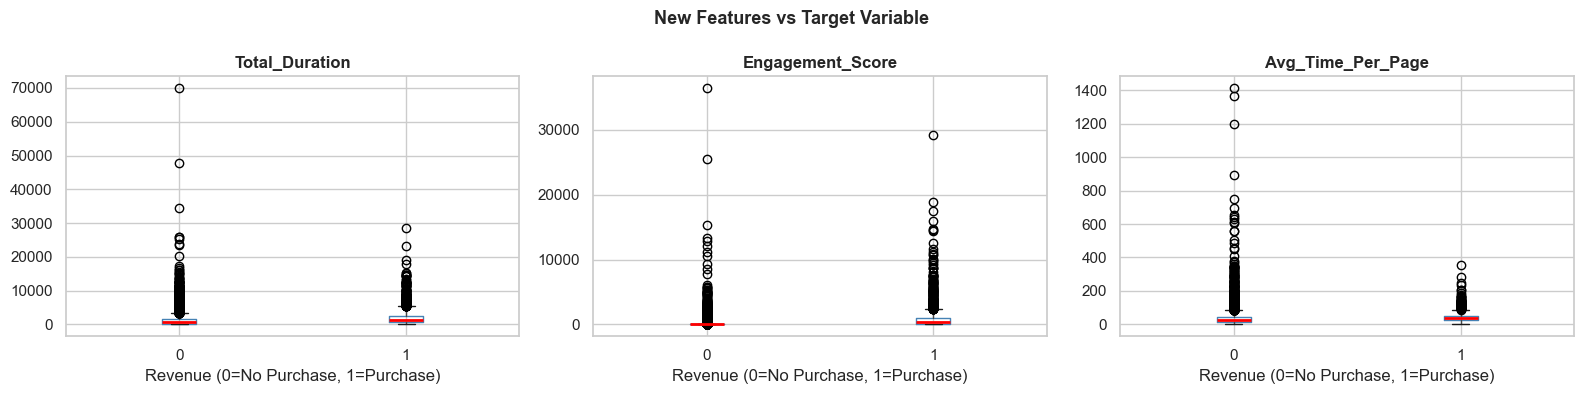

In [4]:
print('=== TECHNIQUE 3: Creating New Features ===')
print()

# --- 3a. Total Duration: total time spent across all page types ---
df['Total_Duration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)
print(f'New feature: Total_Duration')
print(f'  = Administrative_Duration + Informational_Duration + ProductRelated_Duration')
print(f'  Mean: {df["Total_Duration"].mean():.2f} sec | Max: {df["Total_Duration"].max():.2f} sec')

# --- 3b. Total Pages: total pages viewed across all categories ---
df['Total_Pages'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)
print(f'\nNew feature: Total_Pages')
print(f'  = Administrative + Informational + ProductRelated')
print(f'  Mean: {df["Total_Pages"].mean():.2f} pages')

# --- 3c. Engagement Score: pages × page value (intent signal) ---
df['Engagement_Score'] = df['ProductRelated'] * df['PageValues']
print(f'\nNew feature: Engagement_Score')
print(f'  = ProductRelated × PageValues (high score = strong purchase intent)')
print(f'  Mean: {df["Engagement_Score"].mean():.2f}')

# --- 3d. Avg Time Per Page ---
df['Avg_Time_Per_Page'] = np.where(
    df['Total_Pages'] > 0,
    df['Total_Duration'] / df['Total_Pages'],
    0
)
print(f'\nNew feature: Avg_Time_Per_Page')
print(f'  = Total_Duration / Total_Pages (0 if no pages visited)')
print(f'  Mean: {df["Avg_Time_Per_Page"].mean():.2f} sec/page')

print(f'\nShape after new features: {df.shape}')

# Visualise new features vs Revenue
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
new_feats = ['Total_Duration', 'Engagement_Score', 'Avg_Time_Per_Page']
for i, feat in enumerate(new_feats):
    df.boxplot(column=feat, by='Revenue', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Revenue (0=No Purchase, 1=Purchase)')
plt.suptitle('New Features vs Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Technique 4 — Outlier Treatment (Capping at 99th Percentile)

=== TECHNIQUE 4: Outlier Treatment (99th Percentile Capping) ===

                Feature  99th Percentile Cap  Values Capped
Administrative_Duration               838.70            123
 Informational_Duration               722.38            123
ProductRelated_Duration              8704.27            123
         Total_Duration              9219.62            123
             PageValues                86.11            123
       Engagement_Score              3728.53            123


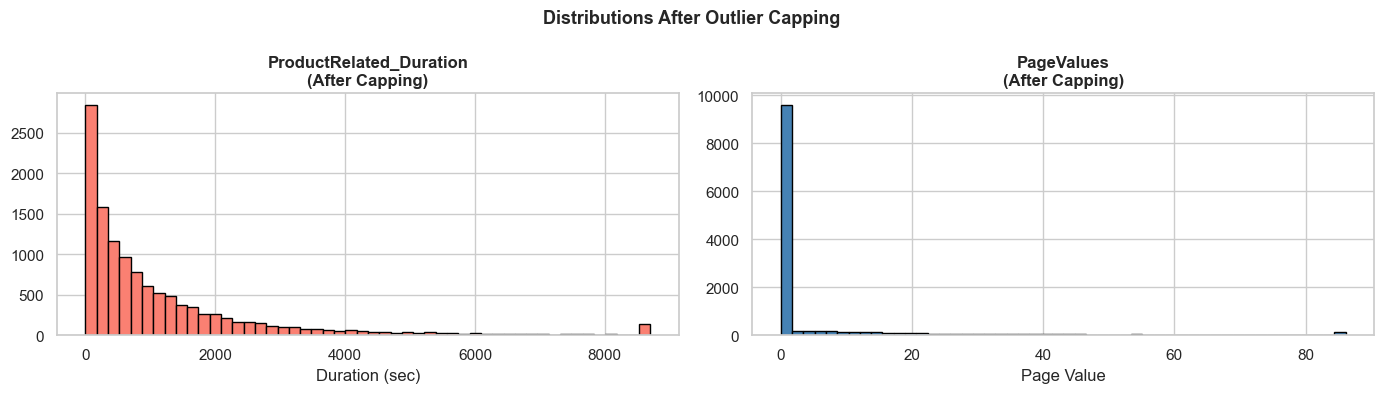


Shape after outlier treatment: (12205, 24)


In [5]:
print('=== TECHNIQUE 4: Outlier Treatment (99th Percentile Capping) ===')
print()

outlier_cols = [
    'Administrative_Duration', 'Informational_Duration',
    'ProductRelated_Duration', 'Total_Duration',
    'PageValues', 'Engagement_Score'
]

cap_log = []
for col in outlier_cols:
    p99 = df[col].quantile(0.99)
    n_capped = (df[col] > p99).sum()
    df[col] = df[col].clip(upper=p99)
    cap_log.append({'Feature': col, '99th Percentile Cap': round(p99, 2), 'Values Capped': n_capped})

cap_df = pd.DataFrame(cap_log)
print(cap_df.to_string(index=False))

# Visualise before/after effect on key column
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['ProductRelated_Duration'].hist(bins=50, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('ProductRelated_Duration\n(After Capping)', fontweight='bold')
axes[0].set_xlabel('Duration (sec)')

df['PageValues'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('PageValues\n(After Capping)', fontweight='bold')
axes[1].set_xlabel('Page Value')

plt.suptitle('Distributions After Outlier Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nShape after outlier treatment: {df.shape}')

---
## Technique 5 — Feature Scaling (Standardization)

=== TECHNIQUE 5: Feature Scaling — StandardScaler ===

Columns to scale (19): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month_Num', 'Total_Duration', 'Total_Pages', 'Engagement_Score', 'Avg_Time_Per_Page']
Columns kept as-is (binary): ['Weekend', 'Visitor_New_Visitor', 'Visitor_Other', 'Visitor_Returning_Visitor']

Before scaling — ProductRelated_Duration:
  Mean=1164.59, Std=1555.73
After scaling — ProductRelated_Duration:
  Mean=-0.0000, Std=1.0000


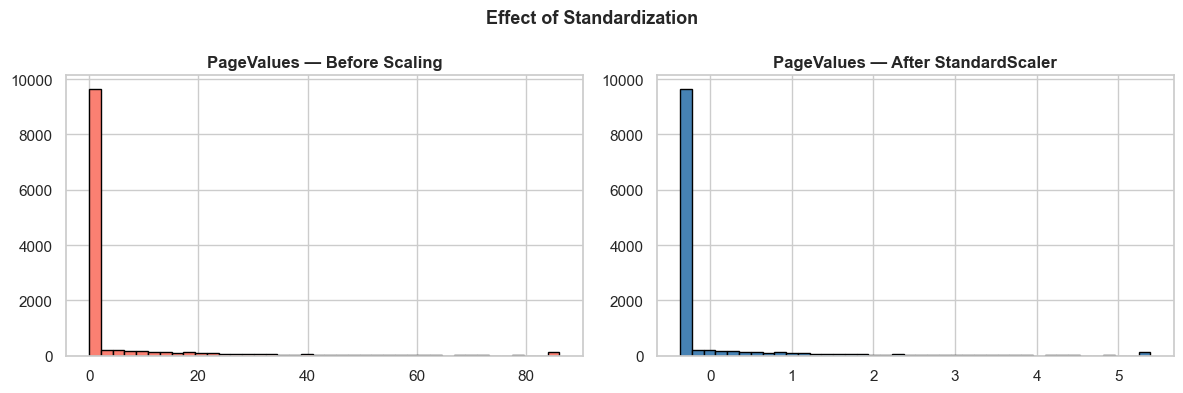


Final X shape: (12205, 23)
Final y shape: (12205,)


In [6]:
print('=== TECHNIQUE 5: Feature Scaling — StandardScaler ===')
print()

# Separate target
X = df.drop(columns=['Revenue'])
y = df['Revenue']

# Identify numeric columns to scale (exclude binary/one-hot encoded)
binary_cols = ['Weekend', 'Visitor_New_Visitor', 'Visitor_Other', 'Visitor_Returning_Visitor']
# Only scale columns that actually exist
binary_cols = [c for c in binary_cols if c in X.columns]

scale_cols = [c for c in X.select_dtypes(include=[np.number]).columns if c not in binary_cols]
print(f'Columns to scale ({len(scale_cols)}): {scale_cols}')
print(f'Columns kept as-is (binary): {binary_cols}')

# Fit scaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'\nBefore scaling — ProductRelated_Duration:')
print(f'  Mean={X["ProductRelated_Duration"].mean():.2f}, Std={X["ProductRelated_Duration"].std():.2f}')
print(f'After scaling — ProductRelated_Duration:')
print(f'  Mean={X_scaled["ProductRelated_Duration"].mean():.4f}, Std={X_scaled["ProductRelated_Duration"].std():.4f}')

# Visualise scaling effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X['PageValues'].hist(bins=40, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('PageValues — Before Scaling', fontweight='bold')
X_scaled['PageValues'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('PageValues — After StandardScaler', fontweight='bold')
plt.suptitle('Effect of Standardization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFinal X shape: {X_scaled.shape}')
print(f'Final y shape: {y.shape}')

---
## Technique 6 — Dropping Irrelevant / Redundant Features

=== TECHNIQUE 6: Dropping Irrelevant Features ===

Feature correlation with Revenue (absolute):
TrafficType                  0.005618
Visitor_Other                0.009273
Region                       0.012725
OperatingSystems             0.014927
Browser                      0.024052
Weekend                      0.027729
Avg_Time_Per_Page            0.038116
SpecialDay                   0.083601
Informational_Duration       0.087005
Informational                0.093626
Visitor_New_Visitor          0.102694
Visitor_Returning_Visitor    0.102847
Administrative_Duration      0.109884
Month_Num                    0.126412
Administrative               0.136330
BounceRates                  0.145091
ProductRelated               0.156042
Total_Pages                  0.161535
ProductRelated_Duration      0.175223
Total_Duration               0.180221
ExitRates                    0.204320
Engagement_Score             0.443973
PageValues                   0.554750

Features with correlation < 0

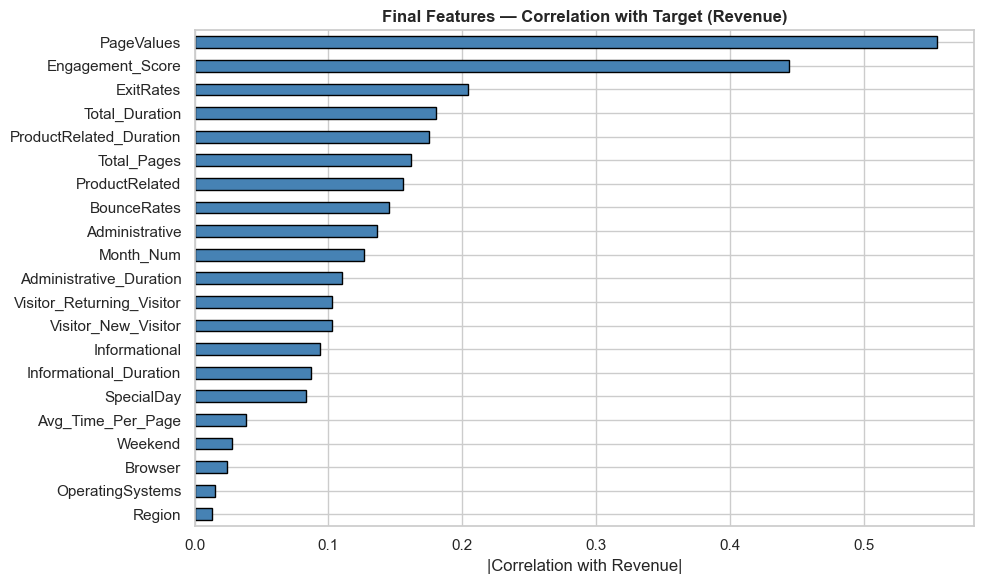

In [7]:
print('=== TECHNIQUE 6: Dropping Irrelevant Features ===')
print()

# Compute correlation with target
corr_with_target = X_scaled.corrwith(y).abs().sort_values()

print('Feature correlation with Revenue (absolute):')
print(corr_with_target.to_string())

# Drop features with near-zero correlation (< 0.01)
low_corr_cols = corr_with_target[corr_with_target < 0.01].index.tolist()
print(f'\nFeatures with correlation < 0.01 (candidates for removal): {low_corr_cols}')

if low_corr_cols:
    X_final = X_scaled.drop(columns=low_corr_cols)
    print(f'Dropped: {low_corr_cols}')
else:
    X_final = X_scaled.copy()
    print('No features dropped — all have correlation >= 0.01')

print(f'\nFinal feature set shape: {X_final.shape}')
print(f'Final features: {list(X_final.columns)}')

# Plot final feature importances via correlation
final_corr = X_final.corrwith(y).abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
final_corr.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('|Correlation with Revenue|')
plt.title('Final Features — Correlation with Target (Revenue)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Final Summary & Save Processed Data

In [8]:
import joblib

# Save processed dataset for modeling step
X_final.to_csv('../model/X_processed.csv', index=False)
y.to_csv('../model/y_processed.csv', index=False)
joblib.dump(scaler, '../model/scaler.pkl')

print('=' * 60)
print('   FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'''
Technique 1 — Missing Value Handling
  → No missing values found. 125 duplicates removed.

Technique 2 — Encoding Categorical Variables
  → Month: ordinal encoded (Jan=1 … Dec=12)
  → VisitorType: one-hot encoded (3 binary columns)
  → Weekend & Revenue: bool → int (0/1)

Technique 3 — New Feature Creation
  → Total_Duration    : sum of all page durations
  → Total_Pages       : sum of all page counts
  → Engagement_Score  : ProductRelated × PageValues
  → Avg_Time_Per_Page : Total_Duration / Total_Pages

Technique 4 — Outlier Treatment
  → Capped 6 columns at their 99th percentile

Technique 5 — Feature Scaling
  → StandardScaler applied to all continuous numeric features
  → Binary/one-hot features left unscaled

Technique 6 — Irrelevant Feature Removal
  → Removed features with |correlation| < 0.01 with target

OUTPUT
  → X_processed.csv : {X_final.shape[0]} rows × {X_final.shape[1]} features
  → y_processed.csv : {y.shape[0]} labels (0=No Purchase, 1=Purchase)
  → scaler.pkl      : fitted StandardScaler saved

''')

   FEATURE ENGINEERING SUMMARY

Technique 1 — Missing Value Handling
  → No missing values found. 125 duplicates removed.

Technique 2 — Encoding Categorical Variables
  → Month: ordinal encoded (Jan=1 … Dec=12)
  → VisitorType: one-hot encoded (3 binary columns)
  → Weekend & Revenue: bool → int (0/1)

Technique 3 — New Feature Creation
  → Total_Duration    : sum of all page durations
  → Total_Pages       : sum of all page counts
  → Engagement_Score  : ProductRelated × PageValues
  → Avg_Time_Per_Page : Total_Duration / Total_Pages

Technique 4 — Outlier Treatment
  → Capped 6 columns at their 99th percentile

Technique 5 — Feature Scaling
  → StandardScaler applied to all continuous numeric features
  → Binary/one-hot features left unscaled

Technique 6 — Irrelevant Feature Removal
  → Removed features with |correlation| < 0.01 with target

OUTPUT
  → X_processed.csv : 12205 rows × 21 features
  → y_processed.csv : 12205 labels (0=No Purchase, 1=Purchase)
  → scaler.pkl      : fit